In [ ]:
#pip install datasets

In [1]:
import nltk
import pandas as pd
import numpy as np
import torch

In [2]:
#from transformers import AutoTokenizer
from datasets import load_dataset

### Uploading from csv file

In [36]:
#Load the CSV file
combined_final = pd.read_csv('combined_ADE_CADEC.csv')
combined_final.head()

,drug,effect,category
0,azithromycin,ototoxicity,Other
1,dihydrotachysterol,increased calcium-release,Other
2,dihydrotachysterol,hypercalcemia,Blood Disorders
3,naproxen,pseudoporphyria,Skin Disorders
4,oxaprozin,pseudoporphyria,Skin Disorders


In [37]:
combined_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6594 entries, 0 to 6593
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   drug      6594 non-null   object
 1   effect    6594 non-null   object
 2   category  6594 non-null   object
dtypes: object(3)
memory usage: 154.7+ KB


In [38]:
combined_final[3:8]

,drug,effect,category
3,naproxen,pseudoporphyria,Skin Disorders
4,oxaprozin,pseudoporphyria,Skin Disorders
5,naproxen,erythropoietic protoporphyria,Other
6,naproxen,cutaneous fragility,Skin Disorders
7,oxaprozin,cutaneous fragility,Skin Disorders


## Starting Modeling

#### Map Each Unique "effect" to a Numerical Label

In [39]:
#Get all unique effects
unique_effects = combined_final['effect'].unique()

#Create a mapping from effect text -> integer ID
effect2id = {effect: idx for idx, effect in enumerate(unique_effects)}
id2effect = {idx: effect for idx, effect in enumerate(unique_effects)}

# Add a new column 'effect_id' to the dataframe
combined_final['effect_id'] = combined_final['effect'].map(effect2id)

#Check!
combined_final[['drug', 'effect', 'effect_id']].head()


,drug,effect,effect_id
0,azithromycin,ototoxicity,0
1,dihydrotachysterol,increased calcium-release,1
2,dihydrotachysterol,hypercalcemia,2
3,naproxen,pseudoporphyria,3
4,oxaprozin,pseudoporphyria,3


#### Prepare Input Data for ClinicalBERT (change 200 here)

In [40]:
# 1. Only keep first 200 samples
train_df_small = combined_final[['drug', 'effect']].iloc[:].copy()

# 2. Create new input_text column
train_df_small['input_text'] = "[DRUG] " + train_df_small['drug'] + " [EFFECT] " + train_df_small['effect']

# 3. Let's check it
print(train_df_small[['input_text']].head())


                                          input_text
0           [DRUG] azithromycin [EFFECT] ototoxicity
1  [DRUG] dihydrotachysterol [EFFECT] increased c...
2   [DRUG] dihydrotachysterol [EFFECT] hypercalcemia
3           [DRUG] naproxen [EFFECT] pseudoporphyria
4          [DRUG] oxaprozin [EFFECT] pseudoporphyria


In [41]:
train_df_small.head()

,drug,effect,input_text
0,azithromycin,ototoxicity,[DRUG] azithromycin [EFFECT] ototoxicity
1,dihydrotachysterol,increased calcium-release,[DRUG] dihydrotachysterol [EFFECT] increased c...
2,dihydrotachysterol,hypercalcemia,[DRUG] dihydrotachysterol [EFFECT] hypercalcemia
3,naproxen,pseudoporphyria,[DRUG] naproxen [EFFECT] pseudoporphyria
4,oxaprozin,pseudoporphyria,[DRUG] oxaprozin [EFFECT] pseudoporphyria


#### Tokenizing

In [42]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
from sklearn.model_selection import train_test_split

In [43]:
# Load ClinicalBERT tokenizer and model
model_name = "emilyalsentzer/Bio_ClinicalBERT"
tokenizer = AutoTokenizer.from_pretrained(model_name)

In [44]:
# Encode the input text
# Split into train/test first
train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_df_small['input_text'].tolist(),
    train_df_small['effect'].tolist(),
    test_size=0.2,  # 20% for validation
    random_state=42
)

# Map labels (effects) to integer IDs
unique_effects = list(set(train_labels + val_labels))
effect2id = {effect: idx for idx, effect in enumerate(unique_effects)}
id2effect = {idx: effect for effect, idx in effect2id.items()}

train_labels = [effect2id[effect] for effect in train_labels]
val_labels = [effect2id[effect] for effect in val_labels]

# Tokenize the texts
train_encodings = tokenizer(train_texts, truncation=True, padding=True)
val_encodings = tokenizer(val_texts, truncation=True, padding=True)

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


In [ ]:
#print(train_labels)

In [ ]:
#print(val_labels)

In [ ]:
#print(train_encodings)

In [ ]:
#print(val_encodings)

#### Create Dataset Objects for PyTorch
##### have tokenized input and labels.
##### need to create PyTorch Dataset objects so ClinicalBERT can use them during training.

In [45]:
# Create a custom Dataset class
class DrugEffectDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

# Create train and validation datasets
train_dataset = DrugEffectDataset(train_encodings, train_labels)
val_dataset = DrugEffectDataset(val_encodings, val_labels)


In [46]:
print(len(train_dataset))
print(train_dataset[0])

5275
{'input_ids': tensor([  101,   164,  3850,   166,  5358,  1605,  6112,  1233,   164,  2629,
          166, 26825,   118,  7449, 17972,  1143,  6473,  4814,   102,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0]), 'token_type_ids': tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]), 'attention_mask': tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]), 'labels': tensor(700)}


### Baselines

In [49]:
from sklearn.metrics import f1_score, accuracy_score
import numpy as np
import pandas as pd

# Use val_labels from your split
true_labels = np.array(val_labels)

# -------------------------------
# Random Baseline
num_classes = len(set(train_labels))  # 25 in this case
random_preds = np.random.randint(0, num_classes, size=len(true_labels))

print("Random Baseline:")
print("F1 Micro :", f1_score(true_labels, random_preds, average='micro'))
print("F1 Macro :", f1_score(true_labels, random_preds, average='macro'))
print("Accuracy:", accuracy_score(true_labels, random_preds))

# -------------------------------
# Most-Frequent Label Baseline
most_freq_label = pd.Series(train_labels).value_counts().idxmax()
most_freq_preds = np.full_like(true_labels, fill_value=most_freq_label)

print("\nMost-Frequent Label Baseline:")
print("F1 Micro :", f1_score(true_labels, most_freq_preds, average='micro'))
print("F1 Macro :", f1_score(true_labels, most_freq_preds, average='macro'))
print("Accuracy:", accuracy_score(true_labels, most_freq_preds))

# -------------------------------
# Drug-Frequency Baseline (based on training data)
train_df = pd.DataFrame({
    "drug": [text.split()[0] for text in train_texts],
    "label": train_labels
})

# Map most common label for each drug
drug_mode_map = train_df.groupby("drug")["label"].agg(lambda x: x.mode().iloc[0])

val_drugs = [text.split()[0] for text in val_texts]
drug_based_preds = [drug_mode_map.get(drug, most_freq_label) for drug in val_drugs]  # default to most_freq_label if not found

print("\nDrug-Frequency Baseline:")
print("F1 Micro :", f1_score(true_labels, drug_based_preds, average='micro'))
print("F1 Macro :", f1_score(true_labels, drug_based_preds, average='macro'))
print("Accuracy:", accuracy_score(true_labels, drug_based_preds))


Random Baseline:
F1 Micro : 0.000758150113722517
F1 Macro : 0.0005367686527106817
Accuracy: 0.000758150113722517

Most-Frequent Label Baseline:
F1 Micro : 0.008339651250947688
F1 Macro : 1.5344483658124903e-05
Accuracy: 0.008339651250947688

Drug-Frequency Baseline:
F1 Micro : 0.008339651250947688
F1 Macro : 1.5344483658124903e-05
Accuracy: 0.008339651250947688


#### Load ClinicalBERT for Classification

In [13]:
# 1. Import model loader
from transformers import AutoModelForSequenceClassification

# 2. How many unique effects you are predicting?
num_labels = len(effect2id)  # You already created effect2id earlier

# 3. Load ClinicalBERT model for sequence classification
model = AutoModelForSequenceClassification.from_pretrained(
    "emilyalsentzer/Bio_ClinicalBERT",
    num_labels=num_labels
)

# 4. Set device (use GPU if available)
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model.to(device)

# 5. Quick check
print(f"Model loaded on: {device}")


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at emilyalsentzer/Bio_ClinicalBERT and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model loaded on: cpu


### Define Loss and Optimizer without weights or categories

In [14]:
# Import necessary things
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim

# Define batch size
batch_size = 8

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)

# Define loss function
loss_fn = nn.CrossEntropyLoss()

# Define optimizer
optimizer = optim.AdamW(model.parameters(), lr=2e-5)

#### Train and validation without categories and weights (not using)

In [15]:
from tqdm import tqdm

#Set number of epochs
epochs = 3

# Move model to training mode
model.train()

for epoch in range(epochs):
    print(f"\nEpoch {epoch+1}/{epochs}")
    total_loss = 0
    correct = 0
    total = 0

    # tqdm for train_loader
    train_bar = tqdm(train_loader, desc="Training", leave=True)

    for batch in train_bar:
        # Move batch to device
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        # Forward pass
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        logits = outputs.logits

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Track total loss
        total_loss += loss.item()

        # Track accuracy
        preds = torch.argmax(logits, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        # Update tqdm bar
        train_bar.set_postfix(loss=loss.item())

    avg_loss = total_loss / len(train_loader)
    accuracy = correct / total

    print(f"Train Loss: {avg_loss:.4f} | Train Accuracy: {accuracy:.4f}")

    # Validation after each epoch
    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0

    val_bar = tqdm(val_loader, desc="Validation", leave=True)

    with torch.no_grad():
        for batch in val_bar:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss
            logits = outputs.logits

            val_loss += loss.item()

            preds = torch.argmax(logits, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

            # Update tqdm bar
            val_bar.set_postfix(loss=loss.item())

    avg_val_loss = val_loss / len(val_loader)
    val_accuracy = val_correct / val_total

    print(f"Validation Loss: {avg_val_loss:.4f} | Validation Accuracy: {val_accuracy:.4f}")

    model.train()  # Set back to train mode after evaluation


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)



Epoch 1/3


Training: 100%|█████████████████████| 660/660 [09:32<00:00,  1.15it/s, loss=7.3]


Train Loss: 8.1902 | Train Accuracy: 0.0095


Validation: 100%|██████████████████| 165/165 [00:24<00:00,  6.73it/s, loss=8.39]


...

Validation Loss: 7.7670 | Validation Accuracy: 0.0394

Epoch 3/3


Training: 100%|█████████████████████| 660/660 [09:36<00:00,  1.14it/s, loss=6.6]


Train Loss: 7.0818 | Train Accuracy: 0.0743


Validation: 100%|██████████████████| 165/165 [00:30<00:00,  5.32it/s, loss=8.68]

Validation Loss: 7.7289 | Validation Accuracy: 0.0675


## Model with Category Prediction

#### convert text categories into numbers

In [16]:
from sklearn.preprocessing import LabelEncoder

# Initialize label encoder
le = LabelEncoder()

# Fit on 'category' column
combined_final['label'] = le.fit_transform(combined_final['category'])

# Check the mapping
label_to_category = dict(zip(le.transform(le.classes_), le.classes_))
print(label_to_category)


{np.int64(0): 'Blood Disorders', np.int64(1): 'Cancer Related Events', np.int64(2): 'Cardiovascular Disorders', np.int64(3): 'Eye Disorders', np.int64(4): 'Fatigue/Weakness', np.int64(5): 'Fever/Temperature Related', np.int64(6): 'Fracture/Bone Disorders', np.int64(7): 'Gastrointestinal Disorders', np.int64(8): 'Hypersensitivity/Allergic Reactions', np.int64(9): 'Immune System Disorders', np.int64(10): 'Infections', np.int64(11): 'Liver Disorders', np.int64(12): 'Metabolic Disorders', np.int64(13): 'Musculoskeletal Disorders', np.int64(14): 'Neurological Disorders', np.int64(15): 'Other', np.int64(16): 'Pain Disorders', np.int64(17): 'Psychiatric Disorders', np.int64(18): 'Renal Disorders', np.int64(19): 'Reproductive Disorders', np.int64(20): 'Respiratory Disorders', np.int64(21): 'Skin Disorders', np.int64(22): 'Therapeutic Complications', np.int64(23): 'Thrombosis/Clotting Disorders'}


#### Prepare Train/Validation Split (change 200 here)

In [17]:
from sklearn.model_selection import train_test_split

# Select first 200 datapoints
small_df = combined_final.iloc[:]

# Split
train_texts, val_texts, train_labels, val_labels = train_test_split(
    small_df['drug'] + " " + small_df['effect'],  # input text: drug + effect
    small_df['label'],                            # output label: category number
    test_size=0.2,
    random_state=42
)

print(f"Train size: {len(train_texts)}, Validation size: {len(val_texts)}")


Train size: 5275, Validation size: 1319


#### Tokenize the Texts

In [18]:
train_encodings = tokenizer(
    list(train_texts),
    truncation=True,
    padding=True
)

val_encodings = tokenizer(
    list(val_texts),
    truncation=True,
    padding=True
)

#### Create New Dataset Class for Category Prediction

In [19]:
import torch

class CategoryDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels.iloc[idx])
        return item

# Create train and validation dataset
train_dataset = CategoryDataset(train_encodings, train_labels)
val_dataset = CategoryDataset(val_encodings, val_labels)


In [20]:
from transformers import AutoModelForSequenceClassification

# Reload ClinicalBERT
model = AutoModelForSequenceClassification.from_pretrained(
    "emilyalsentzer/Bio_ClinicalBERT",
    num_labels=25
)

model.to(device)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at emilyalsentzer/Bio_ClinicalBERT and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(28996, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

#### Create Dataloaders for Category Prediction

In [21]:
from torch.utils.data import DataLoader

# Dataloaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)


### Without weights

#### Set Optimizer and Loss Function

In [22]:
import torch.optim as optim
from torch import nn

# Optimizer
optimizer = optim.AdamW(model.parameters(), lr=2e-5)

# Loss function (automatically applies softmax inside)
criterion = nn.CrossEntropyLoss()

#### Training and Validation without weights

In [23]:
from tqdm import tqdm
from sklearn.metrics import f1_score

epochs = 10

for epoch in range(epochs):
    print(f"\nEpoch {epoch+1}/{epochs}")

    # Training
    model.train()
    train_loss = 0
    correct = 0
    total = 0

    progress_bar = tqdm(train_loader, desc="Training", leave=False)

    for batch in progress_bar:
        optimizer.zero_grad()
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits

        loss = criterion(logits, labels)
        train_loss += loss.item()

        loss.backward()
        optimizer.step()

        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        progress_bar.set_postfix(loss=loss.item())

    train_accuracy = correct / total
    print(f"Train Loss: {train_loss/len(train_loader):.4f} | Train Accuracy: {train_accuracy:.4f}")

    # Validation
    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0

    all_preds = []
    all_labels = []

    val_bar = tqdm(val_loader, desc="Validation", leave=False)

    with torch.no_grad():
        for batch in val_bar:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits

            loss = criterion(logits, labels)
            val_loss += loss.item()

            preds = logits.argmax(dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            val_bar.set_postfix(loss=loss.item())

    val_accuracy = val_correct / val_total
    f1_micro = f1_score(all_labels, all_preds, average='micro', zero_division=0)
    f1_macro = f1_score(all_labels, all_preds, average='macro', zero_division=0)

    print(f"Validation Loss: {val_loss/len(val_loader):.4f} | Validation Accuracy: {val_accuracy:.4f}")
    print(f"F1 Micro: {f1_micro:.4f} | F1 Macro: {f1_macro:.4f}")


Epoch 1/10


Train Loss: 1.6025 | Train Accuracy: 0.6413


Validation Loss: 0.8019 | Validation Accuracy: 0.8704
F1 Micro: 0.8704 | F1 Macro: 0.6222

Epoch 2/10


Train Loss: 0.4296 | Train Accuracy: 0.9331


Validation Loss: 0.2142 | Validation Accuracy: 0.9651
F1 Micro: 0.9651 | F1 Macro: 0.8595

Epoch 3/10


...

Validation Loss: 0.1067 | Validation Accuracy: 0.9795
F1 Micro: 0.9795 | F1 Macro: 0.9707

Epoch 9/10


Train Loss: 0.0202 | Train Accuracy: 0.9968


Validation Loss: 0.1236 | Validation Accuracy: 0.9727
F1 Micro: 0.9727 | F1 Macro: 0.9751

Epoch 10/10


Train Loss: 0.0155 | Train Accuracy: 0.9979


Validation Loss: 0.0961 | Validation Accuracy: 0.9841
F1 Micro: 0.9841 | F1 Macro: 0.9672


#### Confusion Matrix

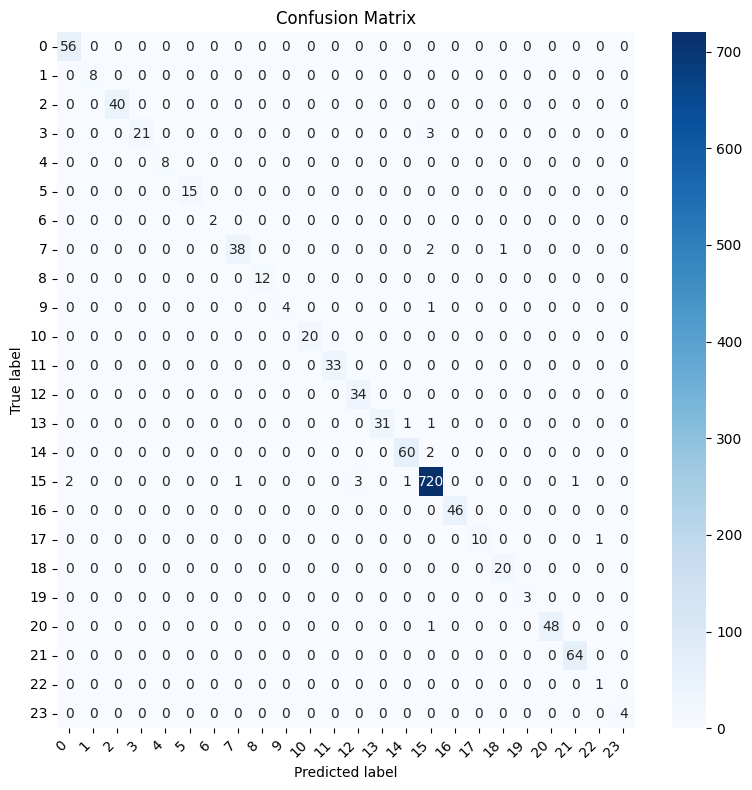

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Plot confusion matrix
plt.figure(figsize=(8, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True)

plt.title("Confusion Matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")

# Rotate axis labels for clarity
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

#### confusion matrix

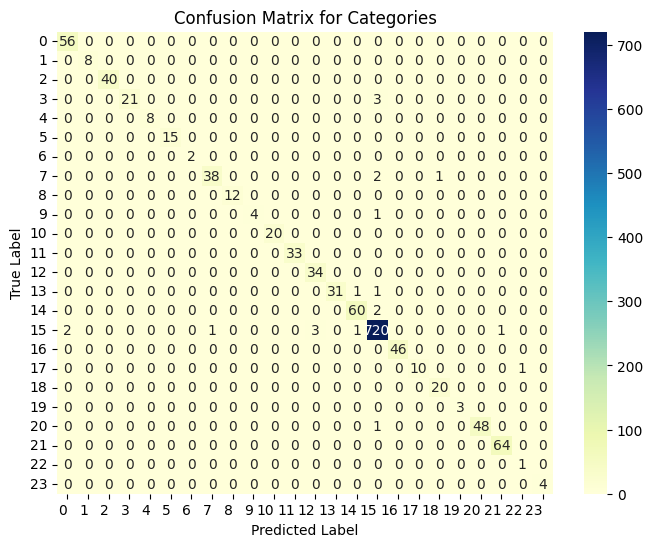

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Assuming these are your labels and predictions
# true_labels: list or array of true class labels
# pred_labels: list or array of predicted class labels

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="YlGnBu")
plt.xticks(rotation=0, ha='right')
plt.yticks(rotation=0)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix for Categories")
plt.show()


### How’s the Model Doing?
Sparse Errors: Most values off the diagonal are zeros or very low, meaning the model is not randomly guessing, but has specific areas of confusion.

Class Imbalance Visible:

Some classes have much higher support (more samples), like class 13.

Some classes have very low counts — possibly leading to poor learning and misclassification.